<a href="https://colab.research.google.com/github/jpandersen61/MySQLNotebooks/blob/main/Linear_Regression_California_Housing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import libraries.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Read in California housing dataset.
from sklearn.datasets import fetch_california_housing


housing = fetch_california_housing()

In [3]:
type(housing)

sklearn.utils._bunch.Bunch

In [4]:
# Create features X and target y.
X = pd.DataFrame(housing.data, columns=housing.feature_names)[["MedInc",	"HouseAge",	"AveRooms",	"AveBedrms","Population","AveOccup","Latitude","Longitude"]]
y = housing.target  # Median house value in $100,000s

### Opgave:



1.   Lav en kode celle herunder og udfør ```X.head()```

2.   Lav en kode celle herunder og udfør ```y```

1.   Forklar hvad ```X``` og ```y``` er

```
# This is formatted as code
```













In [5]:
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [7]:
# Import train_test_split.
from sklearn.model_selection import train_test_split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Opgave



1.   Forklar ovenstående kodecelle




In [9]:
# Import StandardScaler.
from sklearn.preprocessing import StandardScaler

# Instantiate StandardScaler.
scaler = StandardScaler()

# Fit and transform training data.
X_train_scaled = scaler.fit_transform(X_train)

# Also transform test data.
X_test_scaled = scaler.transform(X_test)

### Opgave



1.   Hvad gør `StandardScaler` for os?


In [10]:
# Import LinearRegression.
from sklearn.linear_model import LinearRegression


# Instantiate linear regression model.
model = LinearRegression()

In [11]:
# Fit the model to the training data.
model.fit(X_train_scaled, y_train)

LinearRegression()

In [12]:
# Make predictions on the testing data.
y_pred = model.predict(X_test_scaled)

In [13]:
from sklearn.metrics import mean_squared_error

# Calculate and print MSE.
mse = mean_squared_error(y_test, y_pred)
print(f"Mean squared error: {mse:.4f}")


# Calculate and print RMSE.
rmse = mse ** 0.5
print(f"Root mean squared error: {rmse:.4f}")

Mean squared error: 0.5559
Root mean squared error: 0.7456


### Opgave:



1.   Forklar `mean_square_error` med dine egne ord




In [14]:
print("Intercept:", model.intercept_)


coef_df = pd.DataFrame({"Feature": X.columns, "Coefficient": model.coef_})
print("\nFeature Coefficients:\n", coef_df)

Intercept: 2.0719469373788777

Feature Coefficients:
       Feature  Coefficient
0      MedInc     0.854383
1    HouseAge     0.122546
2    AveRooms    -0.294410
3   AveBedrms     0.339259
4  Population    -0.002308
5    AveOccup    -0.040829
6    Latitude    -0.896929
7   Longitude    -0.869842


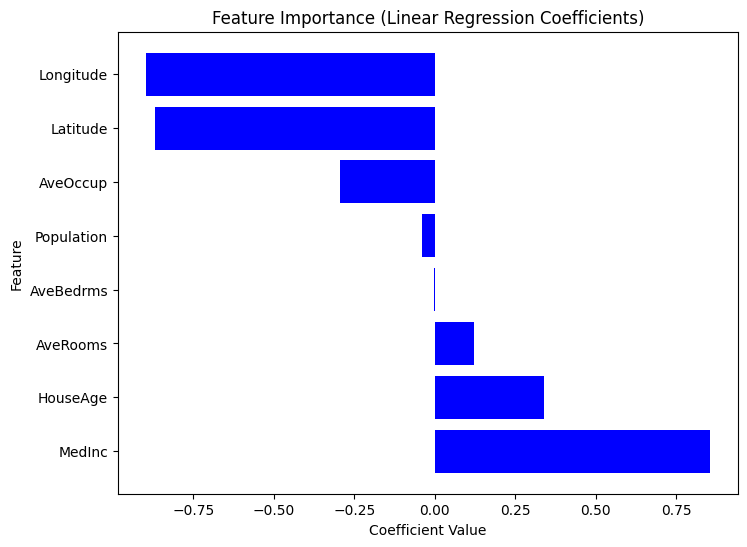

In [15]:
# Sort dataframe by coefficients.
coef_df_sorted = coef_df.sort_values(by="Coefficient", ascending=False)


# Create plot.
plt.figure(figsize=(8,6))
plt.barh(coef_df["Feature"], coef_df_sorted["Coefficient"], color="blue")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.title("Feature Importance (Linear Regression Coefficients)")
plt.show()

### Opgave



1.   Forklar ovenstående diagram


1.   Fjern en eller flere af følgende features og se om der er noget der ændrer sig `"MedInc",	"HouseAge",	"AveRooms",	"AveBedrms","Population","AveOccup","Latitude","Longitude"`. Kør hele note book'en igen efter, at du ændret på valget af features.




